# File and Data Field Descriptions

- **train.csv** - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
  - **PassengerId** - A unique Id for each passenger. Each Id takes the form gggg\*pp where \*\*\_gggg indicates a group the passenger is travelling**\* with and **_pp is their number within the group_\*\*. People in a group are often family members, but not always.
  - **HomePlanet** - The planet the passenger departed from, typically their planet of permanent residence.
  - **CryoSleep** - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
  - **Cabin** - The cabin number where the passenger is staying. Takes the form **_deck/num/side, where side can be either P for Port or S for Starboard_**.
  - **Destination** - The planet the passenger will be debarking to.
  - **Age** - The age of the passenger.
  - **VIP** - Whether the passenger has **_paid for special VIP service_** during the voyage.
  - **RoomService, FoodCourt, ShoppingMall, Spa, VRDeck** - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
  - **Name** - The first and last names of the passenger.
  - **Transported** - Whether the passenger was transported to another dimension. **This is the target**, the column you are trying to predict.
- **test.csv** - Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. Your task is to predict the value of Transported for the passengers in this set.
- **sample_submission.csv** - A submission file in the correct format.
  - **PassengerId** - Id for each passenger in the test set.
  - **Transported** - The target. For each passenger, predict either True or False.


**Todo:**

- Unbekannte Werte auffuellen
  - Name: werte koennen mit der PassengerId ergaenzt werden
  - HomePlanet: kann man dem haeufigsten vorkommenden ergaenzt werden "Eearth"
  - CryoSleep: Wenn Nachname gleich oder Cabin gleich dann Mehrheitsbestimmung, sonst "False" setzten.
- Kombiniere "RoomService, FoodCourt, ShoppingMall, Spa, VRDeck" zu Spalte "Total"
- one-hot:
  - VIP, da nur T/F
  - CryoSleep
  - HomePlanet -> droppen, da noise
- Age zu bins
- Cabins:
  - Bei Duplikaten zu Spalte "FamilySize" hinzufügen
  - Deck koennte man binen
  - side zu one-hot
  - num koennte man droppen oder zu bins umwandeln
- Name: eventuell zu "isAlone" umwandeln und droppen
- PassengerId: unterteilen in Gruppe wie "\_gggg"
- Destination: Mit Dest + Homeplanet = Duration -> Long, medium, short -> Vorhersagen, ob Cryosleep


In [1]:
# data analysis and wrangling
import pandas as pd
import numpy as np
import random as rnd

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# machine learning
from scipy.stats import chi2_contingency
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron, SGDClassifier, LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix


SEED = 42
np.random.seed(SEED)

In [2]:
df_train = pd.read_csv("./data/spaceship-titanic/train.csv")
df_test = pd.read_csv("./data/spaceship-titanic/test.csv")

labels = df_train["Transported"]
# y_test = df_test["Transported"]

# df_train.drop(["Transported"], axis=1, inplace=True)
# df_test.drop(["Transported"], axis=1, inplace=True)

In [3]:
labels

0       False
1        True
2       False
3       False
4        True
        ...  
8688    False
8689    False
8690     True
8691    False
8692     True
Name: Transported, Length: 8693, dtype: bool

In [35]:
combined = pd.concat([df_train, df_test], sort=False).reset_index(drop=True)
combined.isnull().sum()

PassengerId        0
HomePlanet       288
CryoSleep        310
Cabin            299
Destination      274
Age              270
VIP              296
RoomService      263
FoodCourt        289
ShoppingMall     306
Spa              284
VRDeck           268
Name             294
Transported     4277
dtype: int64

In [5]:
# Jeder Passanger ist einzigartig.
#
combined.select_dtypes(include=["O"]).nunique()

PassengerId    12970
HomePlanet         3
CryoSleep          2
Cabin           9825
Destination        3
VIP                2
Name           12629
Transported        2
dtype: int64

In [6]:
combined.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,12700.000000,12707.000000,12681.000000,12664.000000,12686.000000,12702.000000
mean,28.771969,222.897852,451.961675,174.906033,308.476904,306.789482
std,14.387261,647.596664,1584.370747,590.558690,1130.279641,1180.097223
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,49.000000,77.000000,29.000000,57.000000,42.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [36]:
test = combined.copy()

test["LastName"] = test["Name"].apply(lambda x: str(x).split(" ")[-1] if pd.notnull(x) else x)
test["GroupId"] = test["PassengerId"].apply(lambda x: str(x).split("_")[0] if pd.notnull(x) else x)

count_name = test.groupby(["GroupId", "LastName"])["PassengerId"].transform("count")
count_cabin = test.groupby(["GroupId", "Cabin"])["PassengerId"].transform("count")

test["FamilySize"] = np.maximum(count_name, count_cabin)

test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

test[test["FamilySize"] > 1].sort_values(["GroupId", "FamilySize"], ascending=[False, True])


# test["LastName"] = test.groupby("LastName")["Name"].transform("count")
# test[test["LastName"] > 1].sort_values("LastName", ascending=False)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,LastName,GroupId,FamilySize,IsAlone
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,Hontichre,9280,2.0,0
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True,Hontichre,9280,2.0,0
8685,9275_01,Europa,False,A/97/P,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,Polaton Conable,True,Conable,9275,3.0,0
8686,9275_02,Europa,False,A/97/P,TRAPPIST-1e,32.0,False,1.0,1146.0,0.0,50.0,34.0,Diram Conable,False,Conable,9275,3.0,0
8687,9275_03,Europa,NaN,A/97/P,TRAPPIST-1e,30.0,False,0.0,3208.0,0.0,2.0,330.0,Atlasym Conable,True,Conable,9275,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,0008_03,Europa,False,B/1/P,55 Cancri e,45.0,False,39.0,7295.0,589.0,110.0,124.0,Wezena Flatic,True,Flatic,0008,3.0,0
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True,Jacostaffey,0006,2.0,0
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True,Jacostaffey,0006,2.0,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,Susent,0003,2.0,0


In [37]:
combined["Duration"] = combined.groupby(["Destination", "HomePlanet"])["CryoSleep"].transform("count")

In [49]:
combined[["CryoSleep", "Duration", "Destination", "HomePlanet"]].sort_values(
    by=["CryoSleep", "Duration"], ascending=[False, True]
)

,CryoSleep,Duration,Destination,HomePlanet
1217,True,29.0,PSO J318.5-22,Europa
2218,True,29.0,PSO J318.5-22,Europa
2520,True,29.0,PSO J318.5-22,Europa
6780,True,29.0,PSO J318.5-22,Europa
6966,True,29.0,PSO J318.5-22,Europa
...,...,...,...,...
10252,NaN,NaN,NaN,Europa
10741,NaN,NaN,TRAPPIST-1e,NaN
10984,NaN,NaN,PSO J318.5-22,NaN
11612,NaN,NaN,NaN,Earth


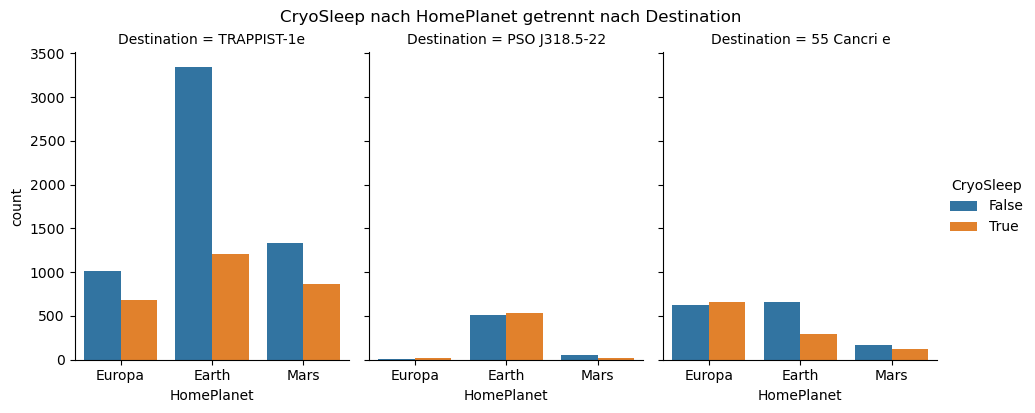

In [128]:
sns.catplot(
    data=combined.dropna(subset=["HomePlanet", "Destination", "CryoSleep"]),
    x="HomePlanet",
    hue="CryoSleep",
    col="Destination",
    kind="count",
    height=4,
    aspect=0.8,
)
plt.suptitle("CryoSleep nach HomePlanet getrennt nach Destination", y=1.02)
plt.show()

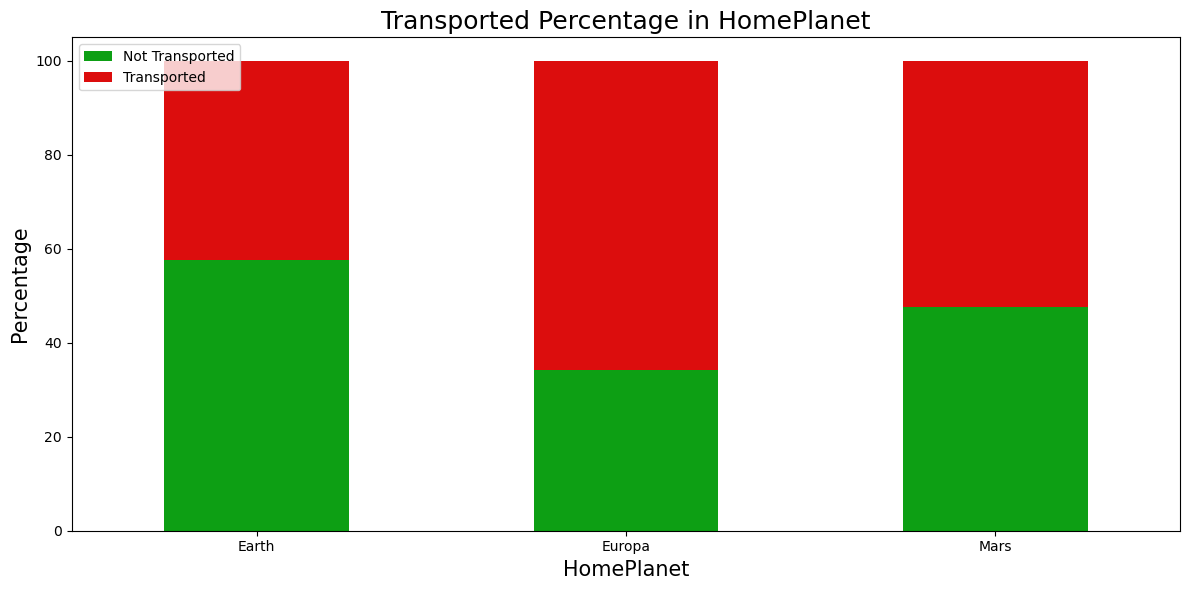

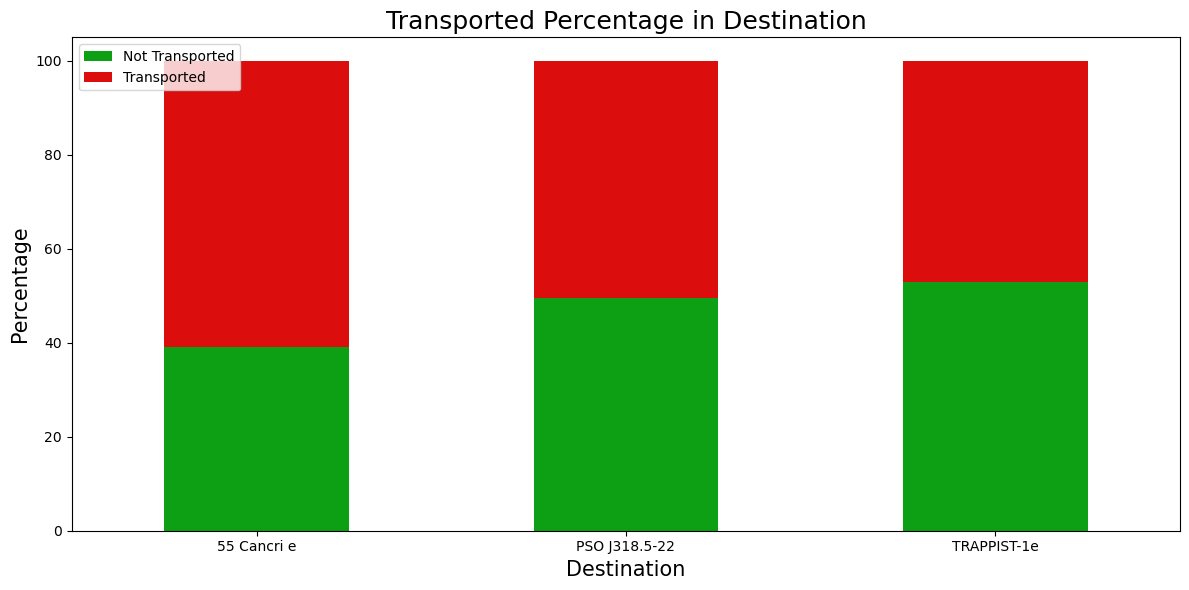

In [121]:
plt_dist_for_col(combined, "HomePlanet", "Transported")
plt_dist_for_col(combined, "Destination", "Transported")

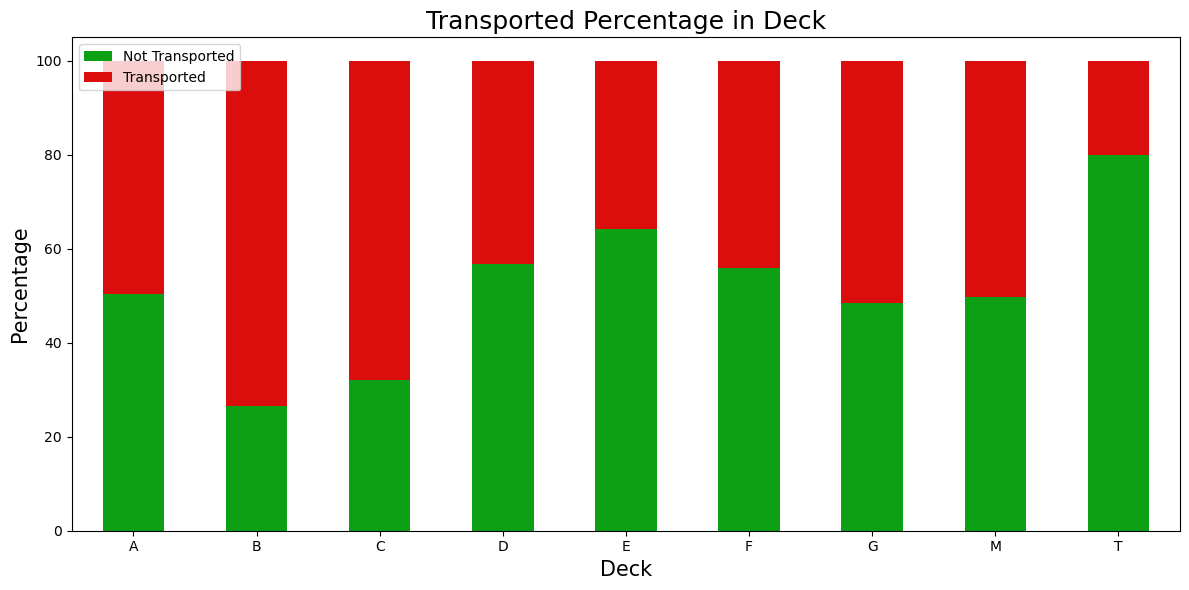

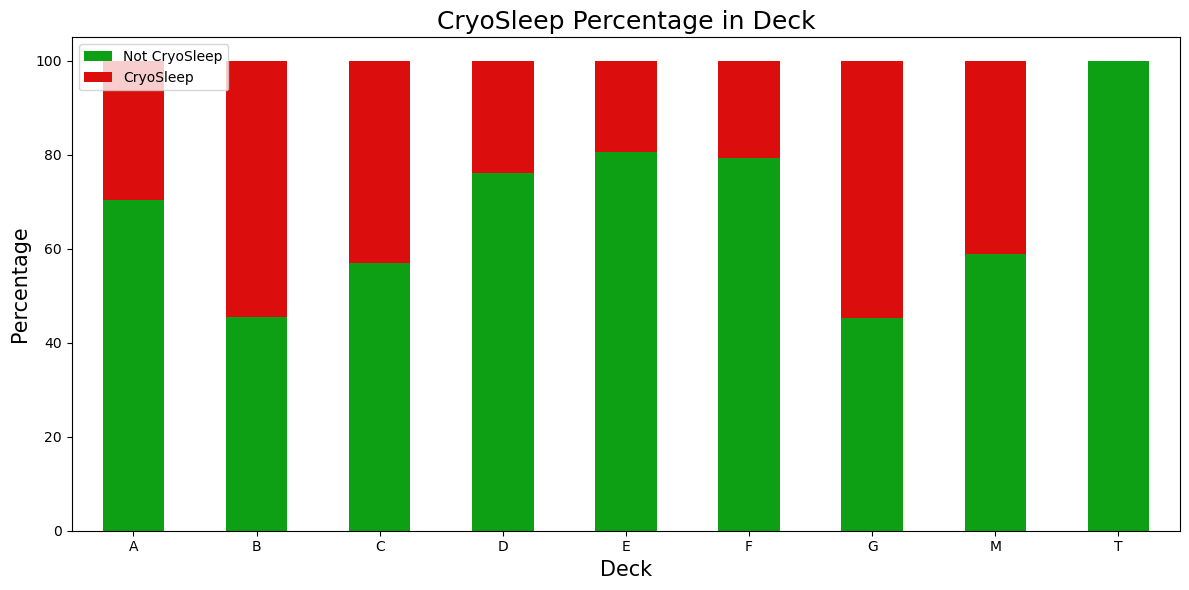

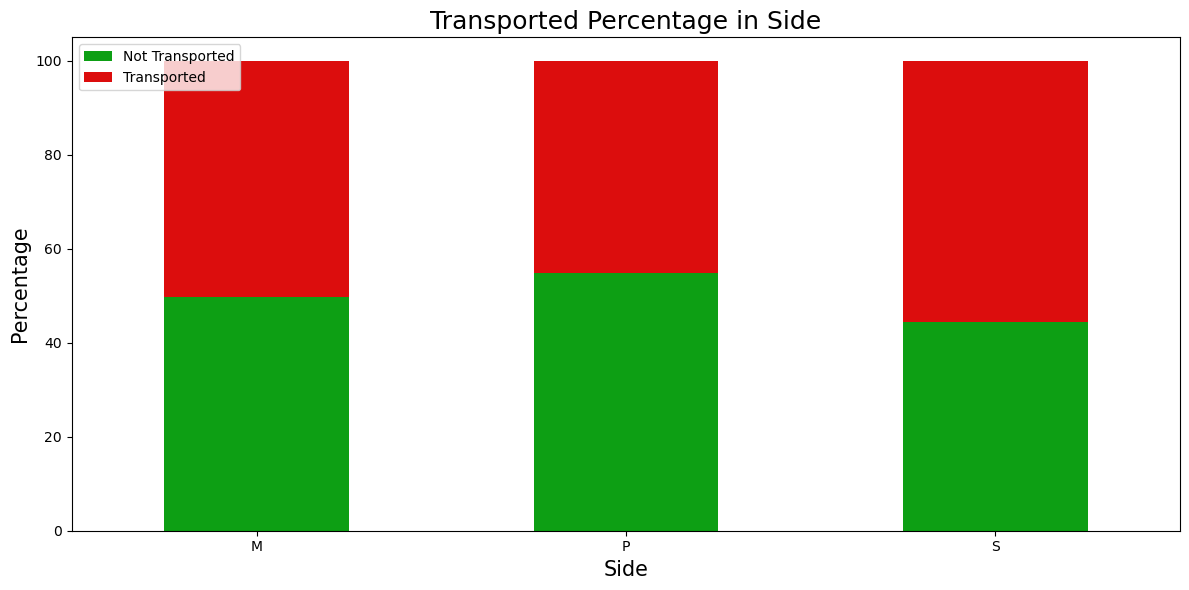

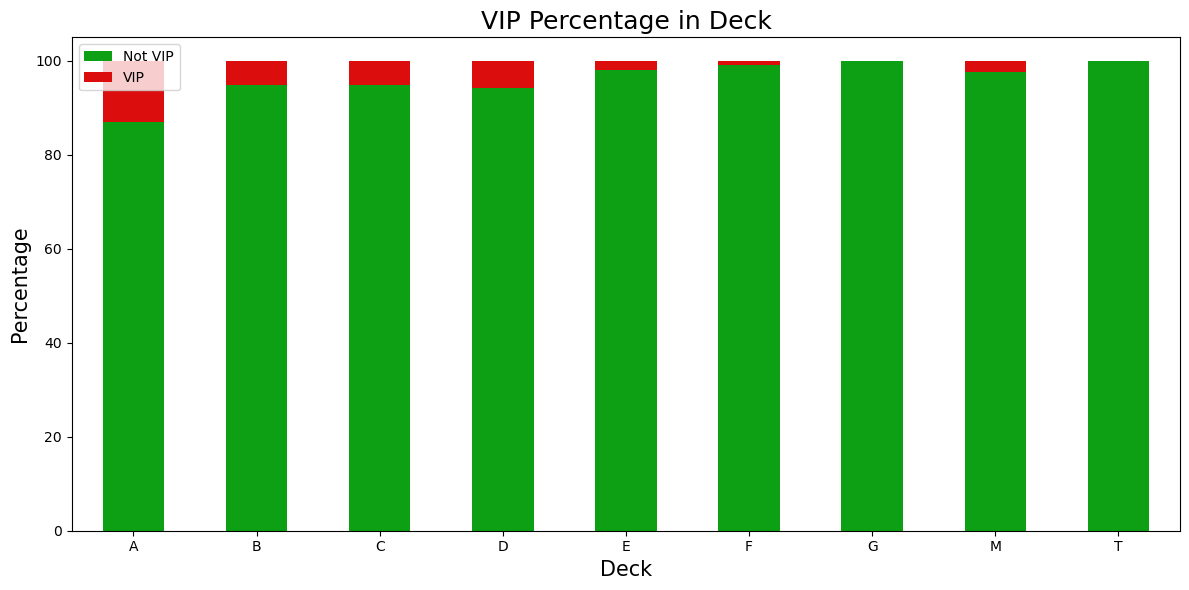

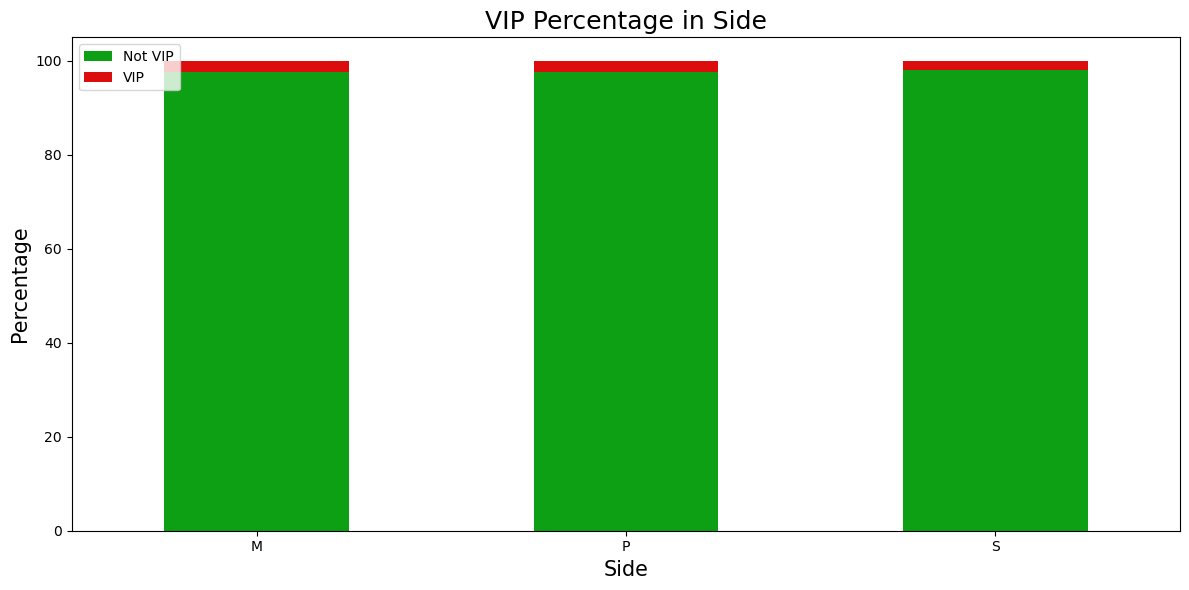

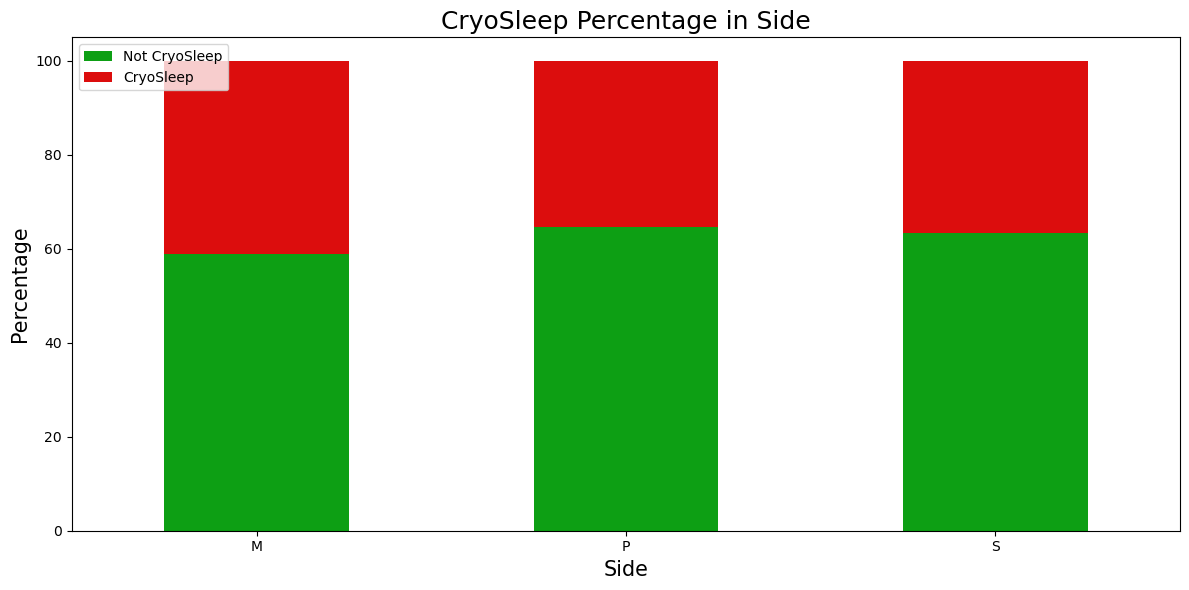

In [ ]:
test = combined.copy()
test["Deck"] = test["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else "M")  # M = Missing
test["Side"] = test["Cabin"].apply(lambda x: str(x).split("/")[2] if pd.notnull(x) else "M")


def plt_dist_for_col(df, col, hue):

    pivot = df.groupby([col, hue]).size().unstack(fill_value=0)
    percentages = pivot.div(pivot.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    percentages.plot(kind="bar", stacked=True, ax=ax, color=["#0d9f14", "#dc0d0d"])
    plt.xlabel(col, size=15)
    plt.ylabel("Percentage", size=15)
    plt.title("{} Percentage in {}".format(hue, col), size=18)
    plt.legend(["Not {}".format(hue), hue], loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


plt_dist_for_col(test, "Deck", "Transported")
plt_dist_for_col(test, "Deck", "CryoSleep")
plt_dist_for_col(test, "Side", "Transported")
plt_dist_for_col(test, "Deck", "VIP")
plt_dist_for_col(test, "Side", "VIP")

### Looking for ways to fill missing values


In [8]:
pd.concat(g for _, g in combined.groupby("Name") if len(g) > 1)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
2404,2589_01,Europa,True,C/91/P,TRAPPIST-1e,26.0,False,0.0,0.0,0.0,0.0,0.0,Alasmon Meteet,True
9286,1219_02,Europa,True,B/52/S,55 Cancri e,23.0,False,0.0,0.0,0.0,0.0,0.0,Alasmon Meteet,NaN
6296,6665_01,Europa,True,B/222/P,55 Cancri e,17.0,False,0.0,0.0,0.0,0.0,0.0,Alraium Disivering,True
7270,7775_01,Europa,False,C/253/P,55 Cancri e,28.0,False,7.0,489.0,0.0,4.0,6027.0,Alraium Disivering,False
476,0512_02,Europa,True,D/18/S,TRAPPIST-1e,55.0,False,0.0,0.0,0.0,0.0,0.0,Ankalik Nateansive,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3381,3640_02,Earth,True,G/589/S,TRAPPIST-1e,41.0,False,0.0,0.0,0.0,0.0,0.0,Troya Schwardson,False
895,0964_02,Europa,True,B/36/P,TRAPPIST-1e,48.0,False,0.0,0.0,0.0,0.0,0.0,Weidus Platch,True
10002,2808_01,Europa,True,C/95/P,55 Cancri e,30.0,False,0.0,0.0,0.0,0.0,0.0,Weidus Platch,NaN
6231,6591_01,Earth,False,F/1261/S,TRAPPIST-1e,47.0,False,285.0,600.0,3.0,0.0,640.0,Willy Mcfarleys,False


In [66]:
# cabins = combined.copy()
combined["Deck"] = combined["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else x)

# cabins["FamilySize"] = cabins.groupby("Cabin")["Cabin"].transform("count")

In [10]:
cabins[cabins["FamilySize"] > 1].sort_values("Cabin", ascending=False)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,FamilySize
11904,7046_01,Europa,False,T/3/S,55 Cancri e,27.0,NaN,6.0,400.0,0.0,6472.0,0.0,Tope Ativeezy,NaN,3.0
11906,7046_03,Europa,False,T/3/S,TRAPPIST-1e,47.0,False,0.0,339.0,0.0,508.0,2000.0,Zinon Ativeezy,NaN,3.0
11905,7046_02,Europa,False,T/3/S,55 Cancri e,44.0,False,0.0,1190.0,0.0,1906.0,167.0,Genubih Ativeezy,NaN,3.0
5826,6168_02,Earth,False,G/999/S,55 Cancri e,12.0,False,0.0,0.0,0.0,0.0,0.0,Glenna Gordond,True,2.0
5825,6168_01,Earth,True,G/999/S,PSO J318.5-22,16.0,False,0.0,0.0,0.0,0.0,0.0,Karie Gordond,True,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52,0056_01,Europa,False,A/1/S,TRAPPIST-1e,2.0,False,0.0,0.0,0.0,0.0,0.0,Okulas Tractive,True,3.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,2.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,2.0
114,0119_02,Europa,True,A/0/P,TRAPPIST-1e,13.0,False,0.0,0.0,0.0,0.0,0.0,Kleeiak Coning,True,2.0


In [11]:
combined[["CryoSleep", "Transported"]].groupby(["CryoSleep"], as_index=False).mean().sort_values(
    by="Transported", ascending=False
)

,CryoSleep,Transported
1,True,0.817583
0,False,0.328921


### Matplotlib experiments


In [13]:
time = np.arange(0.0, 5.0, 0.2)  # (Beginn, End, Steps)
print(time)

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4 2.6 2.8 3.  3.2 3.4
 3.6 3.8 4.  4.2 4.4 4.6 4.8]


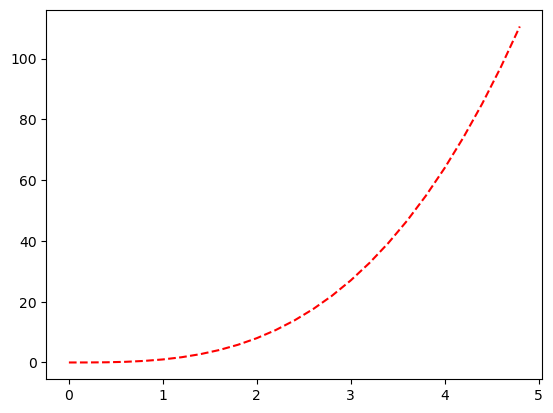

In [14]:
plt.plot(time, time**3, "r--")

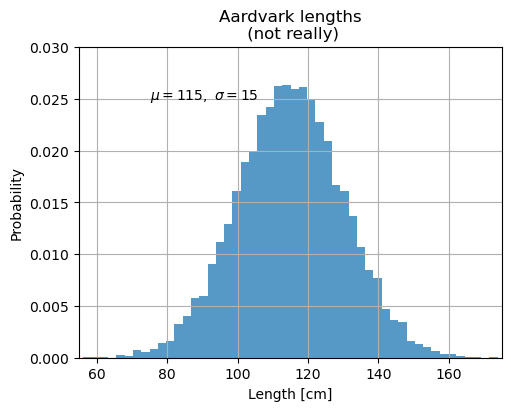

In [15]:
mu, sigma = 115, 15
x = mu + sigma * np.random.randn(10000)
fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")
ax.hist(x, 50, density=True, facecolor="C0", alpha=0.75)

ax.set_xlabel("Length [cm]")
ax.set_ylabel("Probability")
ax.set_title("Aardvark lengths\n (not really)")
ax.text(75, 0.025, r"$\mu=115,\ \sigma=15$")
ax.axis([55, 175, 0, 0.03])
ax.grid(True)

In [16]:
combined.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [17]:
for dataset in combined:
    print(dataset)

PassengerId
HomePlanet
CryoSleep
Cabin
Destination
Age
VIP
RoomService
FoodCourt
ShoppingMall
Spa
VRDeck
Name
Transported


In [ ]:
df_train_copy = df_train.copy()
df_train_copy = df_train_copy.dropna(subset=["Cabin"])
# df_train_copy = df_train_copy.dropna(subset=["VIP"])


df_train_copy["Deck"] = df_train_copy["Cabin"].apply(lambda x: str(x).split("/")[0] if pd.notnull(x) else x)
df_train_copy["Side"] = df_train_copy["Cabin"].apply(lambda x: str(x).split("/")[2] if pd.notnull(x) else x)

df_train_copy.drop(["Name"], axis=1, inplace=True)
df_train_copy.drop(["PassengerId"], axis=1, inplace=True)
df_train_copy.drop(["Cabin"], axis=1, inplace=True)
# df_train_copy.drop(["Age"], axis=1, inplace=True)

cats = df_train_copy.select_dtypes(exclude=[np.number])

for col in cats:  # -1, wenn es Unebkannte werde hat
    df_train_copy[col] = df_train_copy[col].astype("category").cat.codes

# df_train_copy["Transported"] = df_train_copy["Transported"].astype(int)
# df_train_copy["Side"] = df_train_copy["Side"].astype(int)
df_train_copy["VIP"] = df_train_copy["VIP"].fillna(False).astype(int)

df_train_copy["Balance"] = (
    df_train_copy["RoomService"]
    + df_train_copy["FoodCourt"]
    + df_train_copy["ShoppingMall"]
    + df_train_copy["Spa"]
    + df_train_copy["VRDeck"]
)

# df_train_copy.drop(["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"], axis=1, inplace=True)

In [257]:
print(df_train_copy["VIP"].unique())
print(df_train_copy["Deck"].unique())

[0 1]
[1 5 0 6 4 3 2 7]


Personen die eingefroren wurden habe id.R. keine Ausgaben, da die keine Beduerfnisse waehrend der Fahrt haben. Personen mit hohen Ausgaben haben hoehere Ueberlebeschancen, da die vermutlich ofter nicht in der Kabine sind


In [231]:
print(df_train_copy.groupby("CryoSleep")["Balance"].mean(), "\n")

print(df_train_copy.groupby("Transported")["Balance"].mean(), "\n")

print(df_train_copy.groupby(["VIP", "Transported"])["Balance"].mean(), "\n")

print(df_train_copy.groupby("Destination")["Balance"].mean())

CryoSleep
-1    1363.467742
 0    2290.383510
 1       0.000000
Name: Balance, dtype: float64 

Transported
0    2034.140592
1     931.429432
Name: Balance, dtype: float64 

VIP  Transported
-1   0              1953.333333
     1               808.936842
 0   0              1955.351171
     1               874.980596
 1   0              4692.183486
     1              4288.092308
Name: Balance, dtype: float64 

Destination
-1    1358.068750
 0    2241.307202
 1     585.762518
 2    1374.099903
Name: Balance, dtype: float64


In [20]:
# for dataset in combined:
#   dataset["Transported"] = dataset["Transported"].map({"True": 1, "False": 0}).astype(int)

In [258]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(k - 1, r - 1))))

In [ ]:
cats.drop(["Name"], axis=1, inplace=True)
cats.drop(["PassengerId"], axis=1, inplace=True)
cats.drop(["Cabin"], axis=1, inplace=True)

In [259]:
cats = cats.columns.tolist()

corr_matrix = pd.DataFrame(index=cats, columns=cats)

for col1 in cats:
    for col2 in cats:
        corr_matrix.loc[col1, col2] = cramers_v(df_train_copy[col1], df_train_copy[col2])

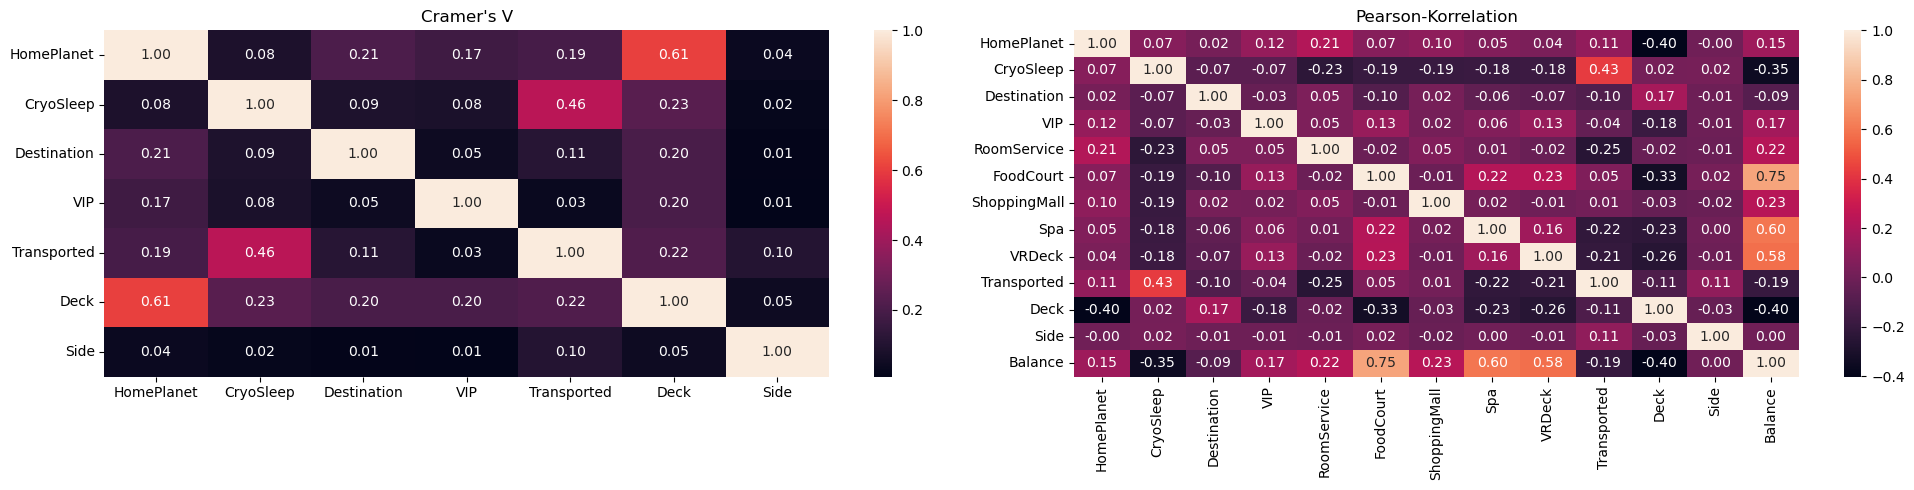

In [260]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix.astype(float), annot=True, fmt=".2f")
plt.title("Cramer's V")

plt.subplot(1, 2, 2)
sns.heatmap(df_train_copy.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f")
plt.title("Pearson-Korrelation")

plt.tight_layout()

### Simple Feature-Engineering, for Validation


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [150]:
combined = pd.concat([df_train, df_test], sort=False).reset_index(drop=True)

In [151]:
combined.drop(["PassengerId", "Name", "Cabin", "Transported"], axis=1, inplace=True)

In [102]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    12682 non-null  object 
 1   CryoSleep     12660 non-null  object 
 2   Destination   12696 non-null  object 
 3   Age           12700 non-null  float64
 4   VIP           12674 non-null  object 
 5   RoomService   12707 non-null  float64
 6   FoodCourt     12681 non-null  float64
 7   ShoppingMall  12664 non-null  float64
 8   Spa           12686 non-null  float64
 9   VRDeck        12702 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1013.4+ KB


- HomePlanet, Destination = Ordinal
- Age = bins
- CryoSleep, VIP = Float
- Cabin, Name, PassengerID = drop


In [152]:
nummeric_imputation = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(combined.select_dtypes(include=[np.number])),
    columns=combined.select_dtypes(include=[np.number]).columns,
)
nummeric_imputation

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0
...,...,...,...,...,...,...
12965,34.0,0.0,0.0,0.0,0.0,0.0
12966,42.0,0.0,847.0,17.0,10.0,144.0
12967,27.0,0.0,0.0,0.0,0.0,0.0
12968,27.0,0.0,2680.0,0.0,0.0,523.0


In [153]:
cat_imputation = pd.DataFrame(
    SimpleImputer(strategy="most_frequent").fit_transform(combined.select_dtypes(exclude=[np.number])),
    columns=combined.select_dtypes(exclude=[np.number]).columns,
)
cat_imputation

,HomePlanet,CryoSleep,Destination,VIP
0,Europa,False,TRAPPIST-1e,False
1,Earth,False,TRAPPIST-1e,False
2,Europa,False,TRAPPIST-1e,True
3,Europa,False,TRAPPIST-1e,False
4,Earth,False,TRAPPIST-1e,False
...,...,...,...,...
12965,Earth,True,TRAPPIST-1e,False
12966,Earth,False,TRAPPIST-1e,False
12967,Mars,True,55 Cancri e,False
12968,Europa,False,TRAPPIST-1e,False


In [154]:
cat = list(combined.select_dtypes(exclude=[np.number]))
num = list(combined.select_dtypes(include=[np.number]))

combined[cat] = cat_imputation
combined[num] = nummeric_imputation
combined.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0


In [155]:
combined["AgeGroup"] = pd.qcut(combined["Age"], 5)
combined.drop("Age", axis=1, inplace=True)

combined["AgeGroup"] = OrdinalEncoder().fit_transform(combined[["AgeGroup"]]).flatten()

In [156]:
combined["VIP"] = combined["VIP"].astype(int)
combined["CryoSleep"] = combined["CryoSleep"].astype(int)

combined = pd.get_dummies(combined, columns=["HomePlanet", "Destination"], prefix=["HomePlanet", "Destination"]).astype(
    int
)

combined

,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,AgeGroup,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,0,0,0,0,0,0,3,0,1,0,0,0,1
1,0,0,109,9,25,549,44,1,1,0,0,0,0,1
2,0,1,43,3576,0,6715,49,4,0,1,0,0,0,1
3,0,0,0,1283,371,3329,193,3,0,1,0,0,0,1
4,0,0,303,70,151,565,2,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,1,0,0,0,0,0,0,3,1,0,0,0,0,1
12966,0,0,0,847,17,10,144,4,1,0,0,0,0,1
12967,1,0,0,0,0,0,0,2,0,0,1,1,0,0
12968,0,0,0,2680,0,0,523,2,0,1,0,0,0,1


In [157]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   CryoSleep                  12970 non-null  int32
 1   VIP                        12970 non-null  int32
 2   RoomService                12970 non-null  int32
 3   FoodCourt                  12970 non-null  int32
 4   ShoppingMall               12970 non-null  int32
 5   Spa                        12970 non-null  int32
 6   VRDeck                     12970 non-null  int32
 7   AgeGroup                   12970 non-null  int32
 8   HomePlanet_Earth           12970 non-null  int32
 9   HomePlanet_Europa          12970 non-null  int32
 10  HomePlanet_Mars            12970 non-null  int32
 11  Destination_55 Cancri e    12970 non-null  int32
 12  Destination_PSO J318.5-22  12970 non-null  int32
 13  Destination_TRAPPIST-1e    12970 non-null  int32
dtypes: int32(14)
memory us

### Model, Training and Prediction


Zu pruefunde Modelle:

- SVC, LinearSVC, Perceptron, SGDClassifier, LogisticRegression
- RandomForestClassifier, XGBClassifier
- KNeighborsClassifier
- GaussianNB
- DecisionTreeClassifier


In [158]:
X_train = combined[: len(df_train)]
y_train = df_train["Transported"]
X_test = combined[len(df_train) :]
X_train.shape, y_train.shape, X_test.shape

((8693, 14), (8693,), (4277, 14))

In [168]:
model_logreg = LogisticRegression(random_state=SEED)
model_logreg.fit(X_train, y_train)
y_pred_logreg = model_logreg.predict(X_test)

acc_log = round(model_logreg.score(X_train, y_train) * 100, 2)
acc_log

c:\Users\alexe\miniconda3\envs\homl3\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


78.25

In [169]:
model_svc = SVC(random_state=SEED)
model_svc.fit(X_train, y_train)
y_pred_svc = model_svc.predict(X_test)

acc_svc = round(model_svc.score(X_train, y_train) * 100, 2)
acc_svc

78.98

In [170]:
model_lsvc = LinearSVC(random_state=SEED)
model_lsvc.fit(X_train, y_train)
y_pred_lsvc = model_lsvc.predict(X_test)

acc_lsvc = round(model_lsvc.score(X_train, y_train) * 100, 2)
acc_lsvc

78.45

In [171]:
model_sgd = SGDClassifier(random_state=SEED)
model_sgd.fit(X_train, y_train)
y_pred_sgd = model_sgd.predict(X_test)

acc_sgd = round(model_sgd.score(X_train, y_train) * 100, 2)
acc_sgd

74.69

In [172]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)

acc_knn = round(model_knn.score(X_train, y_train) * 100, 2)
acc_knn

80.71

In [174]:
model_knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

In [182]:
model_gaus = GaussianNB()
model_gaus.fit(X_train, y_train)
y_pred_gaus = model_gaus.predict(X_test)

acc_gaus = round(model_gaus.score(X_train, y_train) * 100, 2)
acc_gaus

71.44

In [183]:
model_perceptron = Perceptron(random_state=SEED)
model_perceptron.fit(X_train, y_train)
y_pred_perceptron = model_perceptron.predict(X_test)

acc_perceptron = round(model_perceptron.score(X_train, y_train) * 100, 2)
acc_perceptron

71.03

In [184]:
model_dtree = DecisionTreeClassifier(random_state=SEED)
model_dtree.fit(X_train, y_train)
y_pred_dtree = model_dtree.predict(X_test)

acc_dtree = round(model_dtree.score(X_train, y_train) * 100, 2)
acc_dtree

91.36

In [206]:
model_dtree.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [191]:
model_randomforest = RandomForestClassifier(random_state=SEED)
model_randomforest.fit(X_train, y_train)
y_pred_randomforest = model_randomforest.predict(X_test)

acc_randomforest = round(model_randomforest.score(X_train, y_train) * 100, 2)
acc_randomforest

91.36

In [192]:
model_randomforest.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [193]:
model_xgb = XGBClassifier(random_state=SEED)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

acc_xgb = round(model_xgb.score(X_train, y_train) * 100, 2)
acc_xgb

86.07

In [197]:
models = pd.DataFrame(
    {
        "Model": [
            "LinearSVC",
            "SVC",
            "LogisticRegression",
            "SGDClassifier",
            "KNeighborsClassifier",
            "GaussianNB",
            "Perceptron",
            "DecisionTreeClassifier",
            "RandomForestClassifier",
            "XGBClassifier",
        ],
        "Acc": [
            acc_lsvc,
            acc_svc,
            acc_log,
            acc_sgd,
            acc_knn,
            acc_gaus,
            acc_perceptron,
            acc_dtree,
            acc_randomforest,
            acc_xgb,
        ],
    }
)
models.sort_values(by="Acc", ascending=False)

,Model,Acc
7,DecisionTreeClassifier,91.36
8,RandomForestClassifier,91.36
9,XGBClassifier,86.07
4,KNeighborsClassifier,80.71
1,SVC,78.98
0,LinearSVC,78.45
2,LogisticRegression,78.25
3,SGDClassifier,74.69
5,GaussianNB,71.44
6,Perceptron,71.03


In [213]:
submission = pd.DataFrame({"PassengerId": df_test["PassengerId"], "Transported": y_pred_dtree_optimized.astype(bool)})
submission.to_csv("./data/output-submissions/spaceTitanic/SampleDtreeOptSubmission.csv", index=False)

In [ ]:
model_dtree_optimized = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=SEED,
)
model_dtree_optimized.fit(X_train, y_train)
y_pred_dtree_optimized = model_dtree_optimized.predict(X_test)
acc_dtree_optimized = round(model_dtree_optimized.score(X_train, y_train) * 100, 2)
acc_dtree_optimized

79.1